<h2>Инициализация распределения Капчинского-Владимирского</h2>

Распределение Капчинского-Владимирского в четырёхмерном пространстве поперечных координат и углов наклона задаётся следующей формулой:

$$
f(x,x',y,y')=\frac{1}{\pi^2\varepsilon_x\varepsilon_y}\delta
\left(
\frac{\gamma_x x^2 + 2\alpha_x x x' + \beta_x x'^2}{\varepsilon_x}+
\frac{\gamma_y y^2 + 2\alpha_y y y' + \beta_y y'^2}{\varepsilon_y}-
1
\right).
$$

Таким образом, при данном распределении полагается, что точки, представляющий частицы пучка, равномерно распределены по поверхности гиперэллисоида в этом четырёхмерном пространстве.Гиперэллипсоид задаётся уравнением

$$
\mathbf{X^T}Q\mathbf{X}=1,
\hspace{1cm}
\mathbf{X}=
\begin{pmatrix}
x\\
x'\\
y\\
y'
\end{pmatrix}.
$$

Матрица $Q$ квадратичной формы принимает в данном случае вид

$$
Q=
\begin{pmatrix}
\gamma_x/\varepsilon_x & \alpha_x/\varepsilon_x & 0 & 0 \\
\alpha_x/\varepsilon_x & \beta_x /\varepsilon_x & 0 & 0 \\
0 & 0 & \gamma_y/\varepsilon_y & \alpha_y/\varepsilon_y \\
0 & 0 & \alpha_y/\varepsilon_y & \beta_y /\varepsilon_y
\end{pmatrix}.
$$

Цель данной работы - научиться генерировать набор точек согласно этому распределению. Начнём с численного задания каких-либо величин параметров распределения.

In [18]:
import numpy as np

import holoviews as hv
from holoviews import opts
hv.extension('matplotlib')

epsx = 10
betx = 8
alfx = 0
gamx = (1+alfx**2)/betx

epsy = 2
bety = 4
alfy = 0
gamy = (1+alfy**2)/bety

x_max  = np.sqrt(epsx*betx)
xp_max = np.sqrt(epsx*gamx)
y_max  = np.sqrt(epsy*bety)
yp_max = np.sqrt(epsy*gamy)

print(F"x_max = {x_max:10.5f}, x'_max = {xp_max:10.5f}")
print(F"y_max = {y_max:10.5f}, y'_max = {yp_max:10.5f}")

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

x_max =    8.94427, x'_max =    1.11803
y_max =    2.82843, y'_max =    0.70711


Выведем эллипсы в плоскостях $xx'$ и $yy'$ согласно этим параметрам. Для <a href="ellipse.html">реализации</a> этого вывода воспользуемся разложением Холецкого матрицы квадратичной формы:
$$
L_{x,y} = cholesky(Q_{x,y}).
$$

Матрица, задающая отображение окружности на эллипс, может быть вычислена как
$$
M = (L^T)^{-1}.
$$

:Layout
   .Curve.I  :Curve   [x]   (x')
   .Curve.II :Curve   [y]   (y')
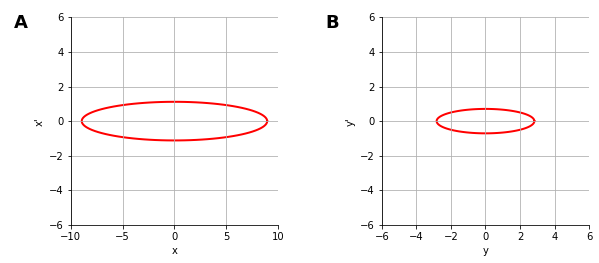

In [19]:
betxn = betx / epsx
alfxn = alfx / epsx
gamxn = gamx / epsx

betyn = bety / epsy
alfyn = alfy / epsy
gamyn = gamy / epsy

Qx = np.array([[gamxn,alfxn],[alfxn,betxn]])
Lx = np.linalg.cholesky(Qx)
Mx = np.linalg.inv(np.matrix.transpose(Lx))

Qy = np.array([[gamyn,alfyn],[alfyn,betyn]])
Ly = np.linalg.cholesky(Qy)
My = np.linalg.inv(np.matrix.transpose(Ly))

ang = np.linspace(0,2*np.pi,100)
XO = [[np.cos(a),np.sin(a)] for a in ang]

Xx = [np.matmul(Mx,XO[k]) for k in range(len(XO))]
Xy = [np.matmul(My,XO[k]) for k in range(len(XO))]

xxdim=hv.Dimension("x", range=(-10, 10))
xpdim=hv.Dimension("x'", range=(-6, 6))
yydim=hv.Dimension("y", range=(-6, 6))
ypdim=hv.Dimension("y'", range=(-6, 6))

Sx = hv.Curve((Xx)).redim(x=xxdim, y=xpdim).opts(show_grid=True, color="red")
Sy = hv.Curve((Xy)).redim(x=yydim, y=ypdim).opts(show_grid=True, color="red")
Sx+Sy

<h3>4-D сфера</h3>

Построим К-В распределение, отобразив равномерно заполненную случайным образом 4-D сферу на гиперэллипсоид. Для заполнения сферы воспользуемся алгоритмом из (<a href="https://dl.acm.org/doi/10.1145/377939.377946">Muller 1959</a>, <a href="https://projecteuclid.org/journals/annals-of-mathematical-statistics/volume-43/issue-2/Choosing-a-Point-from-the-Surface-of-a-Sphere/10.1214/aoms/1177692644.full">Marsaglia 1972</a>).

C:\Users\04806\AppData\Local\Temp\ipykernel_51536\2959831452.py:12: HoloviewsDeprecationWarning: IPython magic is deprecated and will be removed in version 1.23.0.
  get_ipython().run_line_magic('opts', 'Scatter [show_grid=True] (s=5.0)')


:Layout
   .Scatter.I  :Scatter   [x1]   ($x_2$)
   .Scatter.II :Scatter   [x3]   ($x_2$)
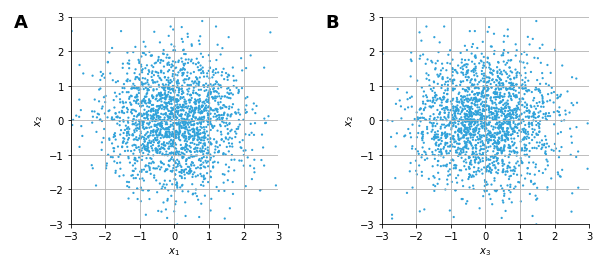

In [20]:
Np = 2000 # number of points
x1 = np.random.normal(loc=0.0, scale=1.0, size=Np)
x2 = np.random.normal(loc=0.0, scale=1.0, size=Np)
x3 = np.random.normal(loc=0.0, scale=1.0, size=Np)
x4 = np.random.normal(loc=0.0, scale=1.0, size=Np)

dim_x1 = hv.Dimension('x1', label='$x_1$', range=(-3,+3))
dim_x2 = hv.Dimension('x2', label='$x_2$', range=(-3,+3))
dim_x3 = hv.Dimension('x3', label='$x_3$', range=(-3,+3))
dim_x4 = hv.Dimension('x4', label='$x_4$', range=(-3,+3))

%opts Scatter [show_grid=True] (s=5.0)

Sc1 = hv.Scatter((x1,x2)).redim(x=dim_x1,y=dim_x2)
Sc2 = hv.Scatter((x3,x2)).redim(x=dim_x3,y=dim_x2)
Sc1+Sc2

Проверим, что проекция точек на любую плоскость двух (в данном случае, безразмерных) координат является равномерной.

:Layout
   .Scatter.I  :Scatter   [x1]   ($x_2$)
   .Scatter.II :Scatter   [x3]   ($x_2$)
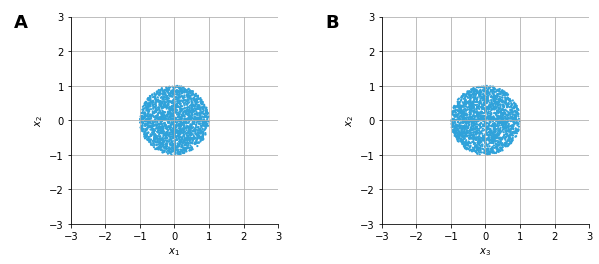

In [21]:
n = np.sqrt(x1*x1 + x2*x2 + x3*x3 + x4*x4)
x1 = x1/n
x2 = x2/n
x3 = x3/n
x4 = x4/n
Sc1 = hv.Scatter((x1,x2)).redim(x=dim_x1,y=dim_x2)
Sc2 = hv.Scatter((x3,x2)).redim(x=dim_x3,y=dim_x2)
Sc1+Sc2

<h3>Построение КВ-распределения</h3>

Для построения отображения 4-D сферы на гиперэллипсоид опять воспользуемя разложением Холецкого, но только сейчас используем полную 4x4 матрицу квадратичной формы $Q$:
$$
L = cholesky(Q).
$$
Как видно, матрица отображения также является блочно-диагональной.

In [22]:
Q = np.array([[gamxn,alfxn,0,0],[alfxn,betxn,0,0],[0,0,gamyn,alfyn],[0,0,alfyn,betyn]])
L = np.linalg.cholesky(Q)
M = np.linalg.inv(np.matrix.transpose(L))
print(M)

[[8.94427191 0.         0.         0.        ]
 [0.         1.11803399 0.         0.        ]
 [0.         0.         2.82842712 0.        ]
 [0.         0.         0.         0.70710678]]


Опять построим проекции точек на плоскости координат $xx'$ и $yy'$. Как видно, они равномерно заполняют ранее приведённые эллипсы! Проекция на $xy$ - тоже равномерно заполненный эллипс с размерами $x_{max}=\sqrt{\varepsilon_x\beta_x}$ и $y_{max}=\sqrt{\varepsilon_y\beta_y}$.

:Layout
   .Overlay.I   :Overlay
      .Curve.I   :Curve   [x]   (x')
      .Scatter.I :Scatter   [x]   (x')
   .Overlay.II  :Overlay
      .Curve.I   :Curve   [y]   (y')
      .Scatter.I :Scatter   [y]   (y')
   .Overlay.III :Overlay
      .Curve.I   :Curve   [x]   (y)
      .Scatter.I :Scatter   [x]   (y)
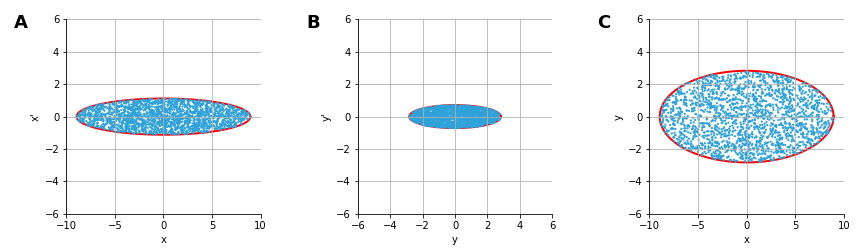

In [23]:
XO4 = np.array([[x1[k],x2[k],x3[k],x4[k]] for k in range(Np)])
X = [np.matmul(M,XO4[k]) for k in range(Np)]
xx = np.array([X[k][0] for k in range(Np)])
xp = np.array([X[k][1] for k in range(Np)])
yy = np.array([X[k][2] for k in range(Np)])
yp = np.array([X[k][3] for k in range(Np)])

SR1 = hv.Scatter((xx,xp)).redim(x=xxdim, y=xpdim)
SR2 = hv.Scatter((yy,yp)).redim(x=yydim, y=ypdim)
SR3 = hv.Scatter((xx,yy)).redim(x=xxdim, y=yydim)

Mxy = np.array([[np.sqrt(epsx*betx),0],[0,np.sqrt(epsy*bety)]])
Xxy = [np.matmul(Mxy,XO[k]) for k in range(len(XO))]
Sxy = hv.Curve((Xxy)).redim(x=xxdim, y=yydim).opts(show_grid=True, color="red")

Sx*SR1+Sy*SR2+Sxy*SR3

<h3>Вторые моменты распределения</h3>

Рассчитаем вторые моменты распределения и среднеквадратичные эмиттансы по $x$ и $y$, сравним их с теоретическими величинами. Как хорошо известно, для равномерно заполненного эллипса

$$
<x^2>=\frac{\varepsilon_x\beta_x}{4},
\hspace{1cm}
<x'^2>=\frac{\varepsilon_x\gamma_x}{4},
\hspace{1cm}
<xx'>=-\frac{\varepsilon_x\alpha_x}{4}.
$$

Итак, расчет для $x$:

In [16]:
midx2   = np.sum(xx*xx)/Np
midx2_t = epsx*betx/4

midxp2   = np.sum(xp*xp)/Np
midxp2_t = epsx*gamx/4

midxxp   = np.sum(xx*xp)/Np
midxxp_t = -epsx*alfx/4

print(F"вычисление <x^2>  = {midx2:10.5f}, теория <x^2>  = {midx2_t:10.5f}")
print(F"вычисление <x'^2> = {midxp2:10.5f}, теория <x'^2> = {midxp2_t:10.5f}")
print(F"вычисление <xx'>  = {midxxp:10.5f}, теория <xx'>  = {midxxp_t:10.5f}")

eps_rmsx = np.sqrt(midx2*midxp2-midxxp**2)
eps_rmsx4= 4*eps_rmsx
print(F"вычисление 4*eps_rms_x  = {eps_rmsx4:10.5f}, eps_x  = {epsx:10.5f}")

вычисление <x^2>  =   12.63373, теория <x^2>  =   12.50000
вычисление <x'^2> =    0.61396, теория <x'^2> =    0.62500
вычисление <xx'>  =    1.27132, теория <xx'>  =    1.25000
вычисление 4*eps_rms_x  =    9.91185, eps_x  =   10.00000


Расчет для $y$ выполняется аналогично:

In [17]:
midy2   = np.sum(yy*yy)/Np
midy2_t = epsy*bety/4

midyp2   = np.sum(yp*yp)/Np
midyp2_t = epsy*gamy/4

midyyp   = np.sum(yy*yp)/Np
midyyp_t = -epsy*alfy/4

print(F"вычисление <y^2>  = {midy2:10.5f}, теория <y^2>  = {midy2_t:10.5f}")
print(F"вычисление <y'^2> = {midyp2:10.5f}, теория <y'^2> = {midyp2_t:10.5f}")
print(F"вычисление <yy'>  = {midyyp:10.5f}, теория <yy'>  = {midyyp_t:10.5f}")

eps_rmsy = np.sqrt(midy2*midyp2-midyyp**2)
eps_rmsy4= 4*eps_rmsy
print(F"вычисление 4*eps_rms_y  = {eps_rmsy4:10.5f}, eps_y  = {epsy:10.5f}")

вычисление <y^2>  =    1.24410, теория <y^2>  =    1.25000
вычисление <y'^2> =    0.22126, теория <y'^2> =    0.21800
вычисление <yy'>  =   -0.14493, теория <yy'>  =   -0.15000
вычисление 4*eps_rms_y  =    2.01699, eps_y  =    2.00000


In [9]:
!jupyter nbconvert --to HTML --TagRemovePreprocessor.remove_cell_tags='{"hide_cell"}' init_kv.ipynb

C:\ProgramData\Anaconda3\lib\site-packages\traitlets\traitlets.py:2202: FutureWarning: Supporting extra quotes around strings is deprecated in traitlets 5.0. You can use 'hide_cell' instead of "'hide_cell'" if you require traitlets >=5.
  warn(
[NbConvertApp] Converting notebook init_kv.ipynb to HTML
[NbConvertApp] Writing 4607993 bytes to init_kv.html
